# Exploring Chemical Space
Explore some clustering and visualisation models and compare them for two different datasets:
- A subset of ChEMBL small molecule entries with a molecular weight between 200 and 500. Since the entire set of ChEMBL entries is quite substantial, 10k entries were selected by random sampling (`chembl_200-500_10k`)
- The result of the PubChem search for "antibiotics" (`pubchem_antibiotics`).

Note: The ChEMBL dataset may still take quite some processing time - depending on your PC. You can do a random sampling of e.g. 3k entries in order to reduce the computational effort.

Tasks:
1) Load and inspect the two datasets `ChEMBL_200-500_10k.csv`. Note that they are fundamentally different.
2) Perform basic data cleaning and be mindful of which data to dismiss (if any). Hint: Think about standardising column names (at least for the relevant ones)
3) Make sure that the SMILES strings are valid - implement a function to clean up the SMILES returning (in a new column or Series) the canonical SMILES if the input is valid, and return `None` if the SMILES in the original data is not valid (). Hint: The `Normalizer` in  rdkit might be quite useful (https://www.rdkit.org/docs/cppapi/classRDKit_1_1MolStandardize_1_1Normalizer.html)
4) Calculate Morgan Fingerprints (radius 2, 2048 bit) from the SMILES strings via mol objects. Make sure not to use the outdated version. You can use either the dataframe, numpy arrays or simple lists for the fingerprints.
5) Run different clustering techniques, e.g. snippets provided for Butina and HDBSCAN. You can also try the scikit-learn models kmeans or dbscan.
6) Use the fingerprints to run UMAP and TSNE dimensionality reductions (snippets provided).
7) Plot the data in scatterplots, using the cluster labels as colour map.
8) Adjust some parameters of the clustering models and apply filters if needed (e.g. only visualise clusters of a size larger than 10) to reach some satisfactory result
9) Visualise a representative molecule (e.g. centroids or centers of clusters, or random :) ) of the three largest clusters for both methods using rdkit
10) Respond to the discussion points


Import dependencies and datasets

In [104]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem.MolStandardize.rdMolStandardize import Normalizer
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from rdkit.Chem import Draw

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import hdbscan
import umap
from sklearn.manifold import TSNE

###m load data

In [2]:
df_chmbl=pd.read_csv("ChEMBL_200-500_10k.csv")
df_pubchem=pd.read_csv("pubchem_antibiotics.csv")



### look at data

In [3]:

df_list=[df_chmbl, df_pubchem]
for df in df_list:
    print("NaN: ",df.isna().sum().sum())
    print("Duplicated: ",df.duplicated().sum().sum())
    print(df.info())
    print(df.describe())
    print("-"*40)


NaN:  31842
Duplicated:  0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ChEMBL ID           10000 non-null  object 
 1   Name                182 non-null    object 
 2   Synonyms            82 non-null     object 
 3   Type                10000 non-null  object 
 4   Max Phase           75 non-null     float64
 5   Molecular Weight    10000 non-null  float64
 6   Targets             9593 non-null   float64
 7   Bioactivities       9593 non-null   float64
 8   AlogP               9946 non-null   float64
 9   Polar Surface Area  9946 non-null   float64
 10  HBA                 9946 non-null   float64
 11  HBD                 9946 non-null   float64
 12  #RO5 Violations     9946 non-null   float64
 13  #Rotatable Bonds    9946 non-null   float64
 14  Passes Ro3          9946 non-null   object 
 15  QED Weighted        9946 no

Data cleaning

In [4]:
for df in df_list:
    #display(df.head())
    #print("-"*40)
    print(df.columns)

Index(['ChEMBL ID', 'Name', 'Synonyms', 'Type', 'Max Phase',
       'Molecular Weight', 'Targets', 'Bioactivities', 'AlogP',
       'Polar Surface Area', 'HBA', 'HBD', '#RO5 Violations',
       '#Rotatable Bonds', 'Passes Ro3', 'QED Weighted', 'Aromatic Rings',
       'Structure Type', 'Inorganic Flag', 'Heavy Atoms', 'Np Likeness Score',
       'Molecular Formula', 'SMILES', 'Inchi Key', 'Inchi', 'Withdrawn Flag',
       'Orphan', 'Records Key', 'Records Name'],
      dtype='object')
Index(['Compound_CID', 'Name', 'Synonyms', 'Molecular_Formula', 'InChI',
       'Smiles', 'InChIKey', 'IUPAC_Name', 'MeSH_Headings',
       'Annotation_Content', 'Linked_BioAssays', 'Data_Source',
       'Data_Source_Category', 'Tagged_by_PubChem', 'Molecular_Weight',
       'Polar_Area', 'Complexity', 'XLogP', 'Heavy_Atom_Count',
       'H-Bond_Donor_Count', 'H-Bond_Acceptor_Count', 'Rotatable_Bond_Count',
       'Exact_Mass', 'Monoisotopic_Mass', 'Charge', 'Covalent_Unit_Count',
       'Isotopic_Atom_Co

### rename cols

In [5]:
def clean_column_names(df):
    df.columns = (df.columns
               .str.strip()
               .str.lower()
               .str.replace(" ", "_")
               .str.replace("[()€$]", "",regex=True))
    return df

# Clean the column names
for df in df_list:
    clean_column_names(df)
    print(df.columns)

Index(['chembl_id', 'name', 'synonyms', 'type', 'max_phase',
       'molecular_weight', 'targets', 'bioactivities', 'alogp',
       'polar_surface_area', 'hba', 'hbd', '#ro5_violations',
       '#rotatable_bonds', 'passes_ro3', 'qed_weighted', 'aromatic_rings',
       'structure_type', 'inorganic_flag', 'heavy_atoms', 'np_likeness_score',
       'molecular_formula', 'smiles', 'inchi_key', 'inchi', 'withdrawn_flag',
       'orphan', 'records_key', 'records_name'],
      dtype='object')
Index(['compound_cid', 'name', 'synonyms', 'molecular_formula', 'inchi',
       'smiles', 'inchikey', 'iupac_name', 'mesh_headings',
       'annotation_content', 'linked_bioassays', 'data_source',
       'data_source_category', 'tagged_by_pubchem', 'molecular_weight',
       'polar_area', 'complexity', 'xlogp', 'heavy_atom_count',
       'h-bond_donor_count', 'h-bond_acceptor_count', 'rotatable_bond_count',
       'exact_mass', 'monoisotopic_mass', 'charge', 'covalent_unit_count',
       'isotopic_atom_co

In [6]:
df_list[0]=df_list[0].rename(columns={"chembl_id": "cid", 
                   "inchi_key": "inchi_key",
                   "rotatable_bonds": "rotatable_bond_count"

                   })
df_list[1]=df_list[1].rename(columns={"compound_cid": "cid", 
                   "polar_surface_area" : "polar_area",
                   "h-bond_acceptor_count": "hba",
                   "h-bond_donor_count": "hbd",
                   "heavy_atom_count":"heavy_atoms"})
for df in df_list:
    print(df.columns)


Index(['cid', 'name', 'synonyms', 'type', 'max_phase', 'molecular_weight',
       'targets', 'bioactivities', 'alogp', 'polar_surface_area', 'hba', 'hbd',
       '#ro5_violations', '#rotatable_bonds', 'passes_ro3', 'qed_weighted',
       'aromatic_rings', 'structure_type', 'inorganic_flag', 'heavy_atoms',
       'np_likeness_score', 'molecular_formula', 'smiles', 'inchi_key',
       'inchi', 'withdrawn_flag', 'orphan', 'records_key', 'records_name'],
      dtype='object')
Index(['cid', 'name', 'synonyms', 'molecular_formula', 'inchi', 'smiles',
       'inchikey', 'iupac_name', 'mesh_headings', 'annotation_content',
       'linked_bioassays', 'data_source', 'data_source_category',
       'tagged_by_pubchem', 'molecular_weight', 'polar_area', 'complexity',
       'xlogp', 'heavy_atoms', 'hbd', 'hba', 'rotatable_bond_count',
       'exact_mass', 'monoisotopic_mass', 'charge', 'covalent_unit_count',
       'isotopic_atom_count', 'total_atom_stereo_count',
       'defined_atom_stereo_count'

In [7]:
df_list_cleaned=df_list.copy()
for df in df_list_cleaned:
    df = df.replace(r'^\s*$', np.nan, regex=True)
    df.dropna(subset=["cid", "smiles"])


[22:24:42] Initializing Normalizer
[22:24:42] Running Normalizer


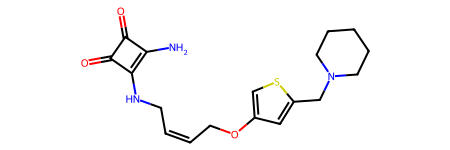

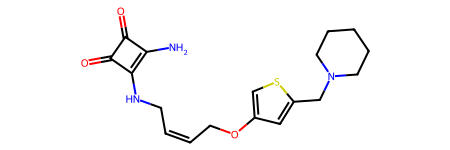

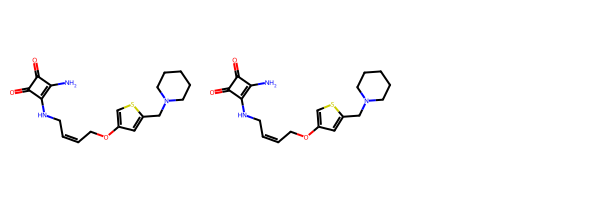

False


In [8]:
nrm=Normalizer()
m=Chem.MolFromSmiles(df_list_cleaned[0]["smiles"][0])
m2 = nrm.normalize(m)
display(m2)
display(m)
display(Draw.MolsToGridImage([m,m2]))
print(m==m2)



In [9]:
nrm = Normalizer()

def valid_smiles(smiles):

    if not isinstance(smiles, str):
        return None

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    try:
        mol = nrm.normalize(mol)
        return Chem.MolToSmiles(mol, canonical=True)
    except:
        return None

[22:24:42] Initializing Normalizer


In [10]:
for df in df_list_cleaned:
    df["valid_smiles"] = df["smiles"].apply(valid_smiles)

[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42] Running Normalizer
[22:24:42]

Calculate Morgan Fingerprints (`GetMorganGenerator`). You can experiment with other fingerprints (`GetRDKitFPGenerator`) as well and see how they impact the clusters.

In [59]:
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
def smiles_to_fp(smiles):
    # string!!!!!!
    if not isinstance(smiles, str):
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    fp = mfpgen.GetFingerprint(mol)
    return fp

In [60]:
# Convert to fingerprints


i=0
fps = []
valid_labels = []
for df in df_list_cleaned:

    for cid, smiles in zip(df["cid"], df["valid_smiles"]):

        fp = smiles_to_fp(smiles)

        if fp is not None:
            fps.append(fp)
            valid_labels.append(cid)

print(fps)
print(valid_labels)


[23:01:51] WARNING: not removing hydrogen atom without neighbors
[23:01:51] WARNING: not removing hydrogen atom without neighbors
[23:01:51] WARNING: not removing hydrogen atom without neighbors
[23:01:51] WARNING: not removing hydrogen atom without neighbors
[23:01:51] WARNING: not removing hydrogen atom without neighbors
[23:01:51] WARNING: not removing hydrogen atom without neighbors
[23:01:51] WARNING: not removing hydrogen atom without neighbors


[<rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x11aafdb60>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x11aafdee0>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x11aafe3b0>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x11aafe180>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x11aafe570>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x11aafe420>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x11aafd5b0>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x11aafd7e0>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x11aafc040>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x11aafd8c0>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x11aafc6d0>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x11aafc5f0>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x11aafc510>, <rdkit.DataStructs.cDataStructs.ExplicitBitVect object at 0x11a

In [ ]:
for df in df_list_cleaned:
    display(df.head())




,cid,name,synonyms,type,max_phase,molecular_weight,targets,bioactivities,alogp,polar_surface_area,...,np_likeness_score,molecular_formula,smiles,inchi_key,inchi,withdrawn_flag,orphan,records_key,records_name,valid_smiles
0,CHEMBL50524,NaN,NaN,Small molecule,NaN,361.47,2.0,2.0,1.96,84.66,...,-0.79,C18H23N3O3S,Nc1c(NC/C=C\COc2csc(CN3CCCCC3)c2)c(=O)c1=O,ZXLCEKMBIFPOSF-DJWKRKHSSA-N,InChI=1S/C18H23N3O3S/c19-15-16(18(23)17(15)22)...,False,-1,['12a'],['3-Amino-4-[(Z)-4-(5-piperidin-1-ylmethyl-thi...,Nc1c(NC/C=C\COc2csc(CN3CCCCC3)c2)c(=O)c1=O
1,CHEMBL1719619,NaN,NaN,Small molecule,NaN,339.35,4.0,4.0,2.33,110.62,...,-0.90,C18H17N3O4,COc1ccc(OC)c(C2C(C#N)=C(N)Oc3cc(C)nc(O)c32)c1,ATRZEYKVGNFNIL-UHFFFAOYSA-N,InChI=1S/C18H17N3O4/c1-9-6-14-16(18(22)21-9)15...,False,-1,"['SID859991', 'SID87345386']","['SID859991', 'SID87345386']",COc1ccc(OC)c(C2C(C#N)=C(N)Oc3cc(C)nc(O)c32)c1
2,CHEMBL1989505,NaN,NaN,Small molecule,NaN,417.54,2.0,2.0,6.02,92.93,...,-1.12,C23H23N5OS,Cc1ccc(NC(=O)Nc2ccc(-c3c(C(C)C)sc4ncnc(N)c34)c...,OCRAIYGHHHMVJB-UHFFFAOYSA-N,InChI=1S/C23H23N5OS/c1-13(2)20-18(19-21(24)25-...,False,-1,['SID103904394'],['SID103904394'],Cc1ccc(NC(=O)Nc2ccc(-c3c(C(C)C)sc4ncnc(N)c34)c...
3,CHEMBL1673052,NaN,NaN,Small molecule,NaN,487.61,3.0,9.0,4.12,77.07,...,-1.28,C27H33N7O2,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc2c(n1)N(C(C)C)c1c...,YYTFTZONXCQXLW-UHFFFAOYSA-N,InChI=1S/C27H33N7O2/c1-18(2)34-22-9-7-6-8-20(2...,False,-1,"['24', 'XMD10-78', 'Compound 18']",['11-isopropyl-2-((2-methoxy-4-(4-methylpipera...,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc2c(n1)N(C(C)C)c1c...
4,CHEMBL3084770,NaN,NaN,Small molecule,NaN,426.56,1.0,1.0,3.58,70.84,...,-0.62,C24H34N4O3,CC[C@H]1COC[C@H](C)N1c1nc2c(C(=O)N[C@@H]3C[C@H...,UIKMHGOYAXJLIA-VPAKFMSCSA-N,InChI=1S/C24H34N4O3/c1-4-17-14-30-13-15(2)28(1...,False,-1,['35'],"['endo-2-((3S,5S)-3-ethyl-5-methylmorpholino)-...",CC[C@H]1COC[C@H](C)N1c1nc2c(C(=O)N[C@@H]3C[C@H...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CHEMBL1877743,NaN,NaN,Small molecule,NaN,420.90,3.0,3.0,5.36,69.04,...,-1.71,C23H21ClN4O2,CC(C)COc1ccc(C(=O)Nc2cc3nn(-c4ccccc4)nc3cc2Cl)cc1,ULVAZAAEJIEJOT-UHFFFAOYSA-N,InChI=1S/C23H21ClN4O2/c1-15(2)14-30-18-10-8-16...,False,-1,['SID24276249'],['SID24276249'],CC(C)COc1ccc(C(=O)Nc2cc3nn(-c4ccccc4)nc3cc2Cl)cc1
9996,CHEMBL1410323,NaN,NaN,Small molecule,NaN,347.68,14.0,18.0,2.73,84.23,...,-1.72,C13H9ClF3N3O3,Cc1nc(C(=O)NNC(=O)c2cccc(Cl)c2)c(C(F)(F)F)o1,SKTQWXALPWUTCU-UHFFFAOYSA-N,InChI=1S/C13H9ClF3N3O3/c1-6-18-9(10(23-6)13(15...,False,-1,['SID26730806'],['SID26730806'],Cc1nc(C(=O)NNC(=O)c2cccc(Cl)c2)c(C(F)(F)F)o1
9997,CHEMBL1565837,NaN,NaN,Small molecule,NaN,248.35,12.0,19.0,3.24,52.89,...,-2.46,C13H16N2OS,CCCC(=O)Nc1sc2c(c1C#N)CCCC2,KLLJJRPAXNCRMB-UHFFFAOYSA-N,InChI=1S/C13H16N2OS/c1-2-5-12(16)15-13-10(8-14...,False,-1,['SID856609'],['SID856609'],CCCC(=O)Nc1sc2c(c1C#N)CCCC2
9998,CHEMBL1234490,TERBUTRYNE,NaN,Small molecule,NaN,241.36,5.0,5.0,2.24,62.73,...,-1.52,C10H19N5S,CCNc1nc(NC(C)(C)C)nc(SC)n1,IROINLKCQGIITA-UHFFFAOYSA-N,"InChI=1S/C10H19N5S/c1-6-11-7-12-8(15-10(2,3)4)...",False,-1,"['SID144213458', 'SID144209280', 'SID26757718'...","['SID144213458', 'SID144209280', 'SID26757718'...",CCNc1nc(NC(C)(C)C)nc(SC)n1


,cid,name,synonyms,molecular_formula,inchi,smiles,inchikey,iupac_name,mesh_headings,annotation_content,...,undefined_atom_stereo_count,total_bond_stereo_count,defined_bond_stereo_count,undefined_bond_stereo_count,linked_pubchem_literature_count,linked_pubchem_patent_count,linked_pubchem_patent_family_count,annotation_type_count,create_date,valid_smiles
0,16131155,Antibiotic A 47934,A-47934 Antibiotic|Antibiotic A 47934|RefChem:...,C58H44Cl3N7O21S,InChI=1S/C58H44Cl3N7O21S/c59-31-7-20-1-4-36(31...,C1[C@@H]2C(=O)N[C@@H](C3=CC(=CC(=C3)OC4=C(C=CC...,HRGFAEUWEMDRRZ-QLRHZSCISA-N,"(1S,2R,19R,22R,34S,37R,40R,52S)-22-amino-5,15,...",antibiotic A 47934,Classification|Literature|Patents|Taxonomy,...,0,0,0,0,17,60,13,4,20070703,N[C@H]1C(=O)N[C@@H]2Cc3ccc(c(Cl)c3)Oc3cc4cc(c3...
1,6439108,Antibiotic S 632-B1,Antibiotic S 632-B1|121995-32-2|S632-B1|S632-B...,C17H25NO5,InChI=1S/C17H25NO5/c1-9(4-10(2)17-11(3)23-17)1...,CC1C(O1)/C(=C\C(C)C(=O)CC(CC2CC(=O)NC(=O)C2)O)/C,JEIOGENOOQCFDS-WMZJFQQLSA-N,4-[(Z)-2-hydroxy-5-methyl-7-(3-methyloxiran-2-...,antibiotic S 632-B1,Classification|Literature|Toxicity,...,4,1,1,0,3,0,0,3,20060428,C/C(=C/C(C)C(=O)CC(O)CC1CC(=O)NC(=O)C1)C1OC1C
2,9690107,Antibiotic FK 089,FK-089 antibiotic|Antibiotic FK 089|86070-74-8...,C14H12N4O7S2,InChI=1S/C14H12N4O7S2/c19-8(20)3-25-17-9(6-4-2...,C1C=C(N2[C@H](S1)[C@@H](C2=O)NC(=O)/C(=N\OCC(=...,YVVLVHFJBQEWHH-NSHRYQRRSA-N,"(6R,7R)-7-[[(2Z)-2-(carboxymethoxyimino)-2-(1,...",antibiotic FK 089,Biological Test Results|Classification|Literat...,...,0,1,1,0,2,5,1,4,20061024,O=C(O)CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=CC...
3,125607,Antibiotic A447 C,Antibiotic A447 C|95599-38-5|Antibiotic A447-C...,C60H88N2O20,InChI=1S/C60H88N2O20/c1-12-60(70)26-41(79-46-2...,CCC1(CC(C2=C(C1OC3CC(C(C(O3)C)OC4CCC(C(O4)C)OC...,JCVKGZNZMVGUIP-UHFFFAOYSA-N,"7,10-bis[[4-(dimethylamino)-5-[5-(5-hydroxy-6-...",antibiotic A447 C,Classification|Literature,...,23,0,0,0,1,0,0,2,20050808,CCC1(O)CC(OC2CC(N(C)C)C(OC3CCC(OC4CCC(O)C(C)O4...
4,5487319,DOB-41 antibiotic,Dob-41 antibiotic|Antibiotic dob 41|115666-98-...,C19H18N2O6,InChI=1S/C19H18N2O6/c1-10(27-19(25)15(9-22)26-...,C[C@H](C1=C2C(=CC=C1)N=C3C(=N2)C=CC=C3C(=O)O)O...,OSEDIRANPWGFRX-MEBBXXQBSA-N,6-[(1R)-1-[(2R)-3-hydroxy-2-methoxypropanoyl]o...,DOB-41 antibiotic,Classification|Literature|Patents,...,0,0,0,0,1,5,1,3,20050808,CO[C@H](CO)C(=O)O[C@H](C)c1cccc2nc3c(C(=O)O)cc...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2353,131634493,Zoptarelin Doxorubicin Acetate,Zoptarelin doxorubicin acetate|4IA03SIO30|Zopt...,C97H129N19O32,InChI=1S/C91H117N19O26.3C2H4O2/c1-44(2)31-58(8...,C[C@H]1[C@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](CC...,XBNFJFHLGRBGTL-KICSVHBJSA-N,"acetic acid;[2-[(2S,4S)-4-[(2R,4S,5S,6S)-4-ami...","LHRH, lysine(6)-doxorubicin",Classification|Literature|Patents,...,0,0,0,0,42,6,5,3,20171017,CC(=O)O.CC(=O)O.CC(=O)O.COc1cccc2c1C(=O)c1c(O)...
2354,131750213,Contezolid Acefosamil,Contezolid acefosamil|1807365-35-0|MRX-4 SODIU...,C20H17F3N4NaO8P,"InChI=1S/C20H18F3N4O8P.Na/c1-11(28)35-36(31,32...",CC(=O)OP(=O)(N(C[C@H]1CN(C(=O)O1)C2=CC(=C(C(=C...,JANNTEAGZXJITO-BTQNPOSSSA-M,"sodium acetyloxy-[1,2-oxazol-3-yl-[[(5R)-2-oxo...",NaN,Biological Test Results|Interactions and Pathw...,...,0,0,0,0,8,18,9,8,20171119,CC(=O)OP(=O)([O-])N(C[C@H]1CN(c2cc(F)c(N3C=CC(...
2355,131750285,"(7S,9S)-7-[(2S,4R,5R,6R)-4-amino-6-methyl-5-[(...",NaN,C32H37NO12,InChI=1S/C32H37NO12/c1-14-31(45-21-8-3-4-9-42-...,C[C@@H]1[C@@H]([C@@H](C[C@H](O1)O[C@H]2C[C@@](...,KMSKQZKKOZQFFG-CBFOJMSHSA-N,"(7S,9S)-7-[(2S,4R,5R,6R)-4-amino-6-methyl-5-[(...",NaN,NaN,...,0,0,0,0,0,0,0,0,20171121,COc1cccc2c1C(=O)c1c(O)c3c(c(O)c1C2=O)C[C@@](O)...
2356,131750203,Chromomycins,Chromomycins,C57H82O26,InChI=1S/C57H82O26/c1-21-34(79-40-19-37(53(26(...,C[C@@H]1[C@H]([C@@H](C[C@@H](O1)O[C@H]2[C@@H](...,ZYVSOIYQKUDENJ-ASUJBHBQSA-N,"[(2R,3R,4R,6R)-6-[[(6S,7S)-6-[(2S,4R,5R,6R)-4-...",NaN,Classification|Literature|Patents|Toxicity,...,1,0,0,0,176,7416,2116,4,20171119,COC(C(=O)[C@@H


for mol in df_list_cleaned[0]["smiles"]:
        try:
                m=Chem.MolFromSmiles(mol)
                m2 = nrm.normalize(m)
                
        except:  # Print the SMILES if there was an error in converting
                print(mol)

> check that everything is iO

In [45]:
for i in [0,1]:
    print(np.array(fps[i]))
    print(np.array(valid_labels[i]))
    print("X shape:", np.array(fps[i]).shape)
    print("y shape:", np.array(valid_labels[i]).shape)

    print(len(fps[i])==len(valid_labels[i]))
    print(fps[i])
    print(valid_labels[i])


[[1 0 1 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
['CHEMBL50524' 'CHEMBL1719619' 'CHEMBL1989505' ... 'CHEMBL1565837'
 'CHEMBL1234490' 'CHEMBL204124']
X shape: (9993, 2048)
y shape: (9993,)
True
[array([1, 0, 1, ..., 0, 0, 0], shape=(2048,)), array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)), array([0, 1, 0, ..., 0, 0, 0], shape=(2048,)), array([0, 1, 0, ..., 0, 0, 0], shape=(2048,)), array([0, 1, 0, ..., 0, 0, 0], shape=(2048,)), array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)), array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)), array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)), array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)), array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)), array([0, 1, 0, ..., 0, 0, 0], shape=(2048,)), array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)), array([0, 0, 0, ..., 0, 0, 0], shape=(2048,)), array([0, 1, 0, ..., 0, 0, 0], shape=(2048,)), array([0, 0, 1, ..., 0, 0, 0], shape=(2048,)), array([0, 0, 0, ..., 0, 0, 0],

Butina Clustering: Investigate later how different cutoffs for the similarity affect the clusters.

In [61]:
# Butina clustering requires distance matrix (distance = Tanimoto similarity); 
# fingerprints provided as list in this snippet - adjust as needed!
fp_list=fps.copy()
dists = []
nfps = len(fp_list)

for i in range(1, nfps):
    similarities = DataStructs.BulkTanimotoSimilarity(fp_list[i], fp_list[:i])
    dists.extend([1-x for x in similarities])

# Apply Butina Clustering

# Apply different thresholds later and see how they affect the clustering
cutoff = 0.6  # Tanimoto similarity threshold; e.g. 04 for larger chemical families, 0.7 for tight analogues...

butina_clusters = Butina.ClusterData(
    dists, # similarity based distance matrix
    nfps, # number of fingerprints
    cutoff,
    isDistData=True
)

print("Number of clusters:", len(butina_clusters))

Number of clusters: 7267


In [62]:
# filter out small clusters, rare chemoptypes, ...
clusters_filtered = [c for c in butina_clusters if len(c) >= 10]

butina_labels = np.full(nfps, -1)
for cluster_id, cluster in enumerate(clusters_filtered):
    for id in cluster:
        butina_labels[id] = cluster_id

sizes = [len(c) for c in clusters_filtered]

print("clusters:", len(sizes))
print("mean size:", np.mean(sizes))
print("max size:", np.max(sizes))
print("singletons:", sum(s == 1 for s in sizes))

clusters: 82
mean size: 23.23170731707317
max size: 125
singletons: 0


HDBSCAN Clustering: Inspect how `min_cluster_size` and `min_samples` affect the clusters later on. This might depend quite a lot on the dataset (try 15 and 5 for the PubChem data, <10 and <5 for the ChEMBL)

In [63]:
# use HDBSCAN for clustering
hdbs_clustering = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=2,
    metric="euclidean"
)

hdbs_labels = hdbs_clustering.fit_predict(fp_list)
# print("Number of DBSCAN clusters:",
#       len(set(hdbs_labels)) - (1 if -1 in hdbs_labels else 0))
# print("Noise points:", list(hdbs_labels).count(-1))

In [64]:
print("Number of DBSCAN clusters:",
      len(set(hdbs_labels)) - (1 if -1 in hdbs_labels else 0))
print("Noise points:", list(hdbs_labels).count(-1))

Number of DBSCAN clusters: 65
Noise points: 10777


Embeddings: TSNE and UMAP

In [65]:
# convert fingerprints to numpy
X = np.zeros((nfps, 2048), dtype=int)
for i, fp in enumerate(fp_list):
    DataStructs.ConvertToNumpyArray(fp, X[i])

In [66]:
# Dimensionality reduction by TSNE
umap_model = umap.UMAP(
    n_neighbors=25,
    min_dist=0.2,
    metric="jaccard",
    random_state=42
)

umap_embedding = umap_model.fit_transform(X)

/Users/verityjanerothermelsmith/Library/Mobile Documents/com~apple~CloudDocs/Uni/FS2026/git/DSA104/.venv/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/Users/verityjanerothermelsmith/Library/Mobile Documents/com~apple~CloudDocs/Uni/FS2026/git/DSA104/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [67]:
# Dimensionality reduction by TSNE
tsne_model = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_embedding = tsne_model.fit_transform(X)

Visualise the two clustering methods in the two embeddings (e.g. as subplot). Make sure to label the axes properly.

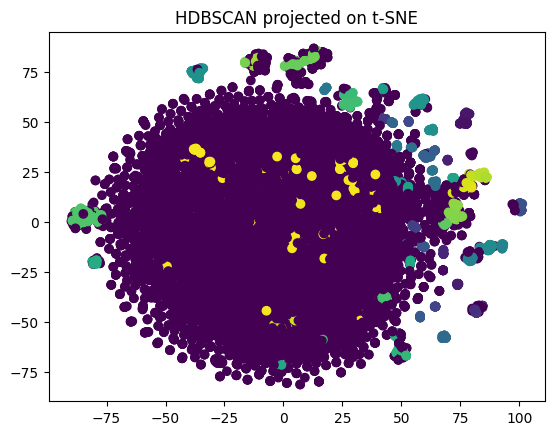

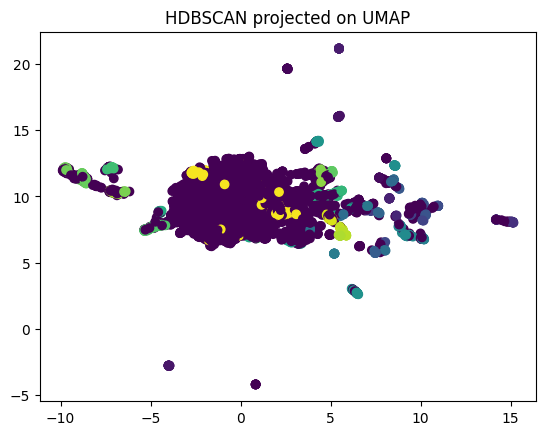

In [68]:
import matplotlib.pyplot as plt

# t-SNE plot
plt.figure()
plt.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], c=hdbs_labels)
plt.title("HDBSCAN projected on t-SNE")
plt.show()


# UMAP plot
plt.figure()
plt.scatter(umap_embedding[:, 0], umap_embedding[:, 1], c=hdbs_labels)
plt.title("HDBSCAN projected on UMAP")
plt.show()

Visualise representative molecules of the three biggest clusters of both methods.

In [97]:
print(len(valid_labels)==len(hdbs_labels))

True


<blockquote>

had to do all this bc didn't think about the fact that I'd need to remap the hdbs labels back to the df. Read through whole noptebook b4 starting next time!!!
</blockquote>

In [121]:
display(df_list_cleaned[0].head())
display(df_list_cleaned[1].head())

,cid,name,synonyms,type,max_phase,molecular_weight,targets,bioactivities,alogp,polar_surface_area,...,molecular_formula,smiles,inchi_key,inchi,withdrawn_flag,orphan,records_key,records_name,valid_smiles,HDBSCAN_cluster
0,CHEMBL50524,NaN,NaN,Small molecule,NaN,361.47,2.0,2.0,1.96,84.66,...,C18H23N3O3S,Nc1c(NC/C=C\COc2csc(CN3CCCCC3)c2)c(=O)c1=O,ZXLCEKMBIFPOSF-DJWKRKHSSA-N,InChI=1S/C18H23N3O3S/c19-15-16(18(23)17(15)22)...,False,-1,['12a'],['3-Amino-4-[(Z)-4-(5-piperidin-1-ylmethyl-thi...,Nc1c(NC/C=C\COc2csc(CN3CCCCC3)c2)c(=O)c1=O,-1
1,CHEMBL1719619,NaN,NaN,Small molecule,NaN,339.35,4.0,4.0,2.33,110.62,...,C18H17N3O4,COc1ccc(OC)c(C2C(C#N)=C(N)Oc3cc(C)nc(O)c32)c1,ATRZEYKVGNFNIL-UHFFFAOYSA-N,InChI=1S/C18H17N3O4/c1-9-6-14-16(18(22)21-9)15...,False,-1,"['SID859991', 'SID87345386']","['SID859991', 'SID87345386']",COc1ccc(OC)c(C2C(C#N)=C(N)Oc3cc(C)nc(O)c32)c1,-1
2,CHEMBL1989505,NaN,NaN,Small molecule,NaN,417.54,2.0,2.0,6.02,92.93,...,C23H23N5OS,Cc1ccc(NC(=O)Nc2ccc(-c3c(C(C)C)sc4ncnc(N)c34)c...,OCRAIYGHHHMVJB-UHFFFAOYSA-N,InChI=1S/C23H23N5OS/c1-13(2)20-18(19-21(24)25-...,False,-1,['SID103904394'],['SID103904394'],Cc1ccc(NC(=O)Nc2ccc(-c3c(C(C)C)sc4ncnc(N)c34)c...,-1
3,CHEMBL1673052,NaN,NaN,Small molecule,NaN,487.61,3.0,9.0,4.12,77.07,...,C27H33N7O2,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc2c(n1)N(C(C)C)c1c...,YYTFTZONXCQXLW-UHFFFAOYSA-N,InChI=1S/C27H33N7O2/c1-18(2)34-22-9-7-6-8-20(2...,False,-1,"['24', 'XMD10-78', 'Compound 18']",['11-isopropyl-2-((2-methoxy-4-(4-methylpipera...,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc2c(n1)N(C(C)C)c1c...,-1
4,CHEMBL3084770,NaN,NaN,Small molecule,NaN,426.56,1.0,1.0,3.58,70.84,...,C24H34N4O3,CC[C@H]1COC[C@H](C)N1c1nc2c(C(=O)N[C@@H]3C[C@H...,UIKMHGOYAXJLIA-VPAKFMSCSA-N,InChI=1S/C24H34N4O3/c1-4-17-14-30-13-15(2)28(1...,False,-1,['35'],"['endo-2-((3S,5S)-3-ethyl-5-methylmorpholino)-...",CC[C@H]1COC[C@H](C)N1c1nc2c(C(=O)N[C@@H]3C[C@H...,-1


,cid,name,synonyms,molecular_formula,inchi,smiles,inchikey,iupac_name,mesh_headings,annotation_content,...,undefined_atom_stereo_count,total_bond_stereo_count,defined_bond_stereo_count,undefined_bond_stereo_count,linked_pubchem_literature_count,linked_pubchem_patent_count,linked_pubchem_patent_family_count,annotation_type_count,create_date,valid_smiles
0,16131155,Antibiotic A 47934,A-47934 Antibiotic|Antibiotic A 47934|RefChem:...,C58H44Cl3N7O21S,InChI=1S/C58H44Cl3N7O21S/c59-31-7-20-1-4-36(31...,C1[C@@H]2C(=O)N[C@@H](C3=CC(=CC(=C3)OC4=C(C=CC...,HRGFAEUWEMDRRZ-QLRHZSCISA-N,"(1S,2R,19R,22R,34S,37R,40R,52S)-22-amino-5,15,...",antibiotic A 47934,Classification|Literature|Patents|Taxonomy,...,0,0,0,0,17,60,13,4,20070703,N[C@H]1C(=O)N[C@@H]2Cc3ccc(c(Cl)c3)Oc3cc4cc(c3...
1,6439108,Antibiotic S 632-B1,Antibiotic S 632-B1|121995-32-2|S632-B1|S632-B...,C17H25NO5,InChI=1S/C17H25NO5/c1-9(4-10(2)17-11(3)23-17)1...,CC1C(O1)/C(=C\C(C)C(=O)CC(CC2CC(=O)NC(=O)C2)O)/C,JEIOGENOOQCFDS-WMZJFQQLSA-N,4-[(Z)-2-hydroxy-5-methyl-7-(3-methyloxiran-2-...,antibiotic S 632-B1,Classification|Literature|Toxicity,...,4,1,1,0,3,0,0,3,20060428,C/C(=C/C(C)C(=O)CC(O)CC1CC(=O)NC(=O)C1)C1OC1C
2,9690107,Antibiotic FK 089,FK-089 antibiotic|Antibiotic FK 089|86070-74-8...,C14H12N4O7S2,InChI=1S/C14H12N4O7S2/c19-8(20)3-25-17-9(6-4-2...,C1C=C(N2[C@H](S1)[C@@H](C2=O)NC(=O)/C(=N\OCC(=...,YVVLVHFJBQEWHH-NSHRYQRRSA-N,"(6R,7R)-7-[[(2Z)-2-(carboxymethoxyimino)-2-(1,...",antibiotic FK 089,Biological Test Results|Classification|Literat...,...,0,1,1,0,2,5,1,4,20061024,O=C(O)CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=CC...
3,125607,Antibiotic A447 C,Antibiotic A447 C|95599-38-5|Antibiotic A447-C...,C60H88N2O20,InChI=1S/C60H88N2O20/c1-12-60(70)26-41(79-46-2...,CCC1(CC(C2=C(C1OC3CC(C(C(O3)C)OC4CCC(C(O4)C)OC...,JCVKGZNZMVGUIP-UHFFFAOYSA-N,"7,10-bis[[4-(dimethylamino)-5-[5-(5-hydroxy-6-...",antibiotic A447 C,Classification|Literature,...,23,0,0,0,1,0,0,2,20050808,CCC1(O)CC(OC2CC(N(C)C)C(OC3CCC(OC4CCC(O)C(C)O4...
4,5487319,DOB-41 antibiotic,Dob-41 antibiotic|Antibiotic dob 41|115666-98-...,C19H18N2O6,InChI=1S/C19H18N2O6/c1-10(27-19(25)15(9-22)26-...,C[C@H](C1=C2C(=CC=C1)N=C3C(=N2)C=CC=C3C(=O)O)O...,OSEDIRANPWGFRX-MEBBXXQBSA-N,6-[(1R)-1-[(2R)-3-hydroxy-2-methoxypropanoyl]o...,DOB-41 antibiotic,Classification|Literature|Patents,...,0,0,0,0,1,5,1,3,20050808,CO[C@H](CO)C(=O)O[C@H](C)c1cccc2nc3c(C(=O)O)cc...


In [122]:
print(valid_labels)

['CHEMBL50524', 'CHEMBL1719619', 'CHEMBL1989505', 'CHEMBL1673052', 'CHEMBL3084770', 'CHEMBL1982534', 'CHEMBL2004365', 'CHEMBL1966329', 'CHEMBL314228', 'CHEMBL2170333', 'CHEMBL1471109', 'CHEMBL3438004', 'CHEMBL4107286', 'CHEMBL3468639', 'CHEMBL1335962', 'CHEMBL1254840', 'CHEMBL1185779', 'CHEMBL3450539', 'CHEMBL573935', 'CHEMBL3674103', 'CHEMBL1669293', 'CHEMBL550725', 'CHEMBL1934285', 'CHEMBL1367377', 'CHEMBL1375887', 'CHEMBL4228885', 'CHEMBL3417564', 'CHEMBL1797068', 'CHEMBL266556', 'CHEMBL314498', 'CHEMBL554241', 'CHEMBL3145291', 'CHEMBL4102556', 'CHEMBL3577418', 'CHEMBL362556', 'CHEMBL1089631', 'CHEMBL3603960', 'CHEMBL1558880', 'CHEMBL1430894', 'CHEMBL1389318', 'CHEMBL1416704', 'CHEMBL493456', 'CHEMBL1320078', 'CHEMBL206806', 'CHEMBL240411', 'CHEMBL3192577', 'CHEMBL1571182', 'CHEMBL1564579', 'CHEMBL1607770', 'CHEMBL485370', 'CHEMBL2296063', 'CHEMBL3431059', 'CHEMBL17681', 'CHEMBL1605579', 'CHEMBL1966065', 'CHEMBL3693544', 'CHEMBL121490', 'CHEMBL4092639', 'CHEMBL1362174', 'CHEMBL13185

In [123]:
valid_dfs = []
for df in df_list_cleaned:
    df_valid = df.loc[df["valid_smiles"].notna()].copy()
    temp_list=[]
    for label, hbds in zip(valid_labels, hdbs_labels):
            for cid in df["cid"]:
                if cid == label:
                    temp_list.append(hbds)

    df_valid["HDBSCAN_cluster"]=temp_list
    valid_dfs.append(df_valid)




In [127]:
display(valid_dfs[0].head())
display(valid_dfs[1].head())

,cid,name,synonyms,type,max_phase,molecular_weight,targets,bioactivities,alogp,polar_surface_area,...,molecular_formula,smiles,inchi_key,inchi,withdrawn_flag,orphan,records_key,records_name,valid_smiles,HDBSCAN_cluster
0,CHEMBL50524,NaN,NaN,Small molecule,NaN,361.47,2.0,2.0,1.96,84.66,...,C18H23N3O3S,Nc1c(NC/C=C\COc2csc(CN3CCCCC3)c2)c(=O)c1=O,ZXLCEKMBIFPOSF-DJWKRKHSSA-N,InChI=1S/C18H23N3O3S/c19-15-16(18(23)17(15)22)...,False,-1,['12a'],['3-Amino-4-[(Z)-4-(5-piperidin-1-ylmethyl-thi...,Nc1c(NC/C=C\COc2csc(CN3CCCCC3)c2)c(=O)c1=O,-1
1,CHEMBL1719619,NaN,NaN,Small molecule,NaN,339.35,4.0,4.0,2.33,110.62,...,C18H17N3O4,COc1ccc(OC)c(C2C(C#N)=C(N)Oc3cc(C)nc(O)c32)c1,ATRZEYKVGNFNIL-UHFFFAOYSA-N,InChI=1S/C18H17N3O4/c1-9-6-14-16(18(22)21-9)15...,False,-1,"['SID859991', 'SID87345386']","['SID859991', 'SID87345386']",COc1ccc(OC)c(C2C(C#N)=C(N)Oc3cc(C)nc(O)c32)c1,-1
2,CHEMBL1989505,NaN,NaN,Small molecule,NaN,417.54,2.0,2.0,6.02,92.93,...,C23H23N5OS,Cc1ccc(NC(=O)Nc2ccc(-c3c(C(C)C)sc4ncnc(N)c34)c...,OCRAIYGHHHMVJB-UHFFFAOYSA-N,InChI=1S/C23H23N5OS/c1-13(2)20-18(19-21(24)25-...,False,-1,['SID103904394'],['SID103904394'],Cc1ccc(NC(=O)Nc2ccc(-c3c(C(C)C)sc4ncnc(N)c34)c...,-1
3,CHEMBL1673052,NaN,NaN,Small molecule,NaN,487.61,3.0,9.0,4.12,77.07,...,C27H33N7O2,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc2c(n1)N(C(C)C)c1c...,YYTFTZONXCQXLW-UHFFFAOYSA-N,InChI=1S/C27H33N7O2/c1-18(2)34-22-9-7-6-8-20(2...,False,-1,"['24', 'XMD10-78', 'Compound 18']",['11-isopropyl-2-((2-methoxy-4-(4-methylpipera...,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc2c(n1)N(C(C)C)c1c...,-1
4,CHEMBL3084770,NaN,NaN,Small molecule,NaN,426.56,1.0,1.0,3.58,70.84,...,C24H34N4O3,CC[C@H]1COC[C@H](C)N1c1nc2c(C(=O)N[C@@H]3C[C@H...,UIKMHGOYAXJLIA-VPAKFMSCSA-N,InChI=1S/C24H34N4O3/c1-4-17-14-30-13-15(2)28(1...,False,-1,['35'],"['endo-2-((3S,5S)-3-ethyl-5-methylmorpholino)-...",CC[C@H]1COC[C@H](C)N1c1nc2c(C(=O)N[C@@H]3C[C@H...,-1


,cid,name,synonyms,molecular_formula,inchi,smiles,inchikey,iupac_name,mesh_headings,annotation_content,...,total_bond_stereo_count,defined_bond_stereo_count,undefined_bond_stereo_count,linked_pubchem_literature_count,linked_pubchem_patent_count,linked_pubchem_patent_family_count,annotation_type_count,create_date,valid_smiles,HDBSCAN_cluster
0,16131155,Antibiotic A 47934,A-47934 Antibiotic|Antibiotic A 47934|RefChem:...,C58H44Cl3N7O21S,InChI=1S/C58H44Cl3N7O21S/c59-31-7-20-1-4-36(31...,C1[C@@H]2C(=O)N[C@@H](C3=CC(=CC(=C3)OC4=C(C=CC...,HRGFAEUWEMDRRZ-QLRHZSCISA-N,"(1S,2R,19R,22R,34S,37R,40R,52S)-22-amino-5,15,...",antibiotic A 47934,Classification|Literature|Patents|Taxonomy,...,0,0,0,17,60,13,4,20070703,N[C@H]1C(=O)N[C@@H]2Cc3ccc(c(Cl)c3)Oc3cc4cc(c3...,2
1,6439108,Antibiotic S 632-B1,Antibiotic S 632-B1|121995-32-2|S632-B1|S632-B...,C17H25NO5,InChI=1S/C17H25NO5/c1-9(4-10(2)17-11(3)23-17)1...,CC1C(O1)/C(=C\C(C)C(=O)CC(CC2CC(=O)NC(=O)C2)O)/C,JEIOGENOOQCFDS-WMZJFQQLSA-N,4-[(Z)-2-hydroxy-5-methyl-7-(3-methyloxiran-2-...,antibiotic S 632-B1,Classification|Literature|Toxicity,...,1,1,0,3,0,0,3,20060428,C/C(=C/C(C)C(=O)CC(O)CC1CC(=O)NC(=O)C1)C1OC1C,-1
2,9690107,Antibiotic FK 089,FK-089 antibiotic|Antibiotic FK 089|86070-74-8...,C14H12N4O7S2,InChI=1S/C14H12N4O7S2/c19-8(20)3-25-17-9(6-4-2...,C1C=C(N2[C@H](S1)[C@@H](C2=O)NC(=O)/C(=N\OCC(=...,YVVLVHFJBQEWHH-NSHRYQRRSA-N,"(6R,7R)-7-[[(2Z)-2-(carboxymethoxyimino)-2-(1,...",antibiotic FK 089,Biological Test Results|Classification|Literat...,...,1,1,0,2,5,1,4,20061024,O=C(O)CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=CC...,-1
3,125607,Antibiotic A447 C,Antibiotic A447 C|95599-38-5|Antibiotic A447-C...,C60H88N2O20,InChI=1S/C60H88N2O20/c1-12-60(70)26-41(79-46-2...,CCC1(CC(C2=C(C1OC3CC(C(C(O3)C)OC4CCC(C(O4)C)OC...,JCVKGZNZMVGUIP-UHFFFAOYSA-N,"7,10-bis[[4-(dimethylamino)-5-[5-(5-hydroxy-6-...",antibiotic A447 C,Classification|Literature,...,0,0,0,1,0,0,2,20050808,CCC1(O)CC(OC2CC(N(C)C)C(OC3CCC(OC4CCC(O)C(C)O4...,-1
4,5487319,DOB-41 antibiotic,Dob-41 antibiotic|Antibiotic dob 41|115666-98-...,C19H18N2O6,InChI=1S/C19H18N2O6/c1-10(27-19(25)15(9-22)26-...,C[C@H](C1=C2C(=CC=C1)N=C3C(=N2)C=CC=C3C(=O)O)O...,OSEDIRANPWGFRX-MEBBXXQBSA-N,6-[(1R)-1-[(2R)-3-hydroxy-2-methoxypropanoyl]o...,DOB-41 antibiotic,Classification|Literature|Patents,...,0,0,0,1,5,1,3,20050808,CO[C@H](CO)C(=O)O[C@H](C)c1cccc2nc3c(C(=O)O)cc...,-1


In [129]:
print(valid_dfs[1][valid_dfs[1]["HDBSCAN_cluster"] == 0])

            cid                                               name  \
174    70697970                                         Zorbamycin   
418   101593096                                        Talisomycin   
653   102003556                                   Bleomycin A-5196   
899     5360373                                          Bleomycin   
1327   92135919                                       Bleomycin A5   
1399  155903698  3-[[2-[2-[2-[[(2R,3R)-2-[[(2R,3R,4S)-4-[[(2S,3...   
1686      72511                                         Phleomycin   
1690      84058                         Bleomycin A5 hydrochloride   
1691      84068                                    Isobleomycin A2   
1695   71503445                         Bleomycin A6 hydrochloride   
1762    6321297                                 Peplomycin Sulfate   
1819    5496540                                       Bleomycin B2   
1821    5460769                                       Bleomycin A2   
1962   11672633     

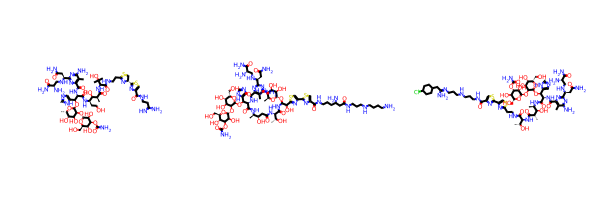

In [130]:
from rdkit import Chem
from rdkit.Chem import Draw

cluster_0 = valid_dfs[1][valid_dfs[1]["HDBSCAN_cluster"] == 0].head(3)

mols = [Chem.MolFromSmiles(sm) for sm in cluster_0["smiles"]]

display(Draw.MolsToGridImage(mols, molsPerRow=3))

## Discussion points
1) What are the characteristics of the chemical spaces described in the two dataset? What is the difference?
2) How do density-based clustering techniques compare to models based on similarity in light of the differences in the datasets?
3) What were the best model parameters for the clustering techniques (i.e. that delivered a meaningful result)
4) Comment on the different dimensionality reduction techniques (again in light of the different dataset characteristics)
5) What was the best / most meaningful combination of dimensionality reduction and clustering methods?
6) Comment on some cheminformatics modelling challenges you may have encountered (e.g. runtime, singleton clusters, paramtersensitivity). What could be done to work around a large number of clusters of small size?
7) On the antibiotics dataset, can you identify some known antibiotic classes / motives in your clusters?
